In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.utils import resample
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import joblib

### Data Loading


In [23]:
df = pd.read_csv('breast-cancer.circ')
df.columns = ['class', 'age', 'menopause', 'tumor_size', 'inv_nodes',
           'node_caps', 'deg_malig', 'breast', 'breast_quad', 'irradiat']
df = pd.read_csv('breast-cancer.circ', names=df.columns, header=None)
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

df.head(50)


,class,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no
5,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,left,left_low,no
6,no-recurrence-events,50-59,premeno,25-29,0-2,no,2,left,left_low,no
7,no-recurrence-events,60-69,ge40,20-24,0-2,no,1,left,left_low,no
8,no-recurrence-events,40-49,premeno,50-54,0-2,no,2,left,left_low,no
9,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,left_up,no


### Exploratory Data Analysis


In [24]:
print(df["class"].value_counts())
print("shape ():", df.shape)
print(df.info())
print(df.describe())
print((df == '?').sum())
print(df.isnull().sum())
print(df.duplicated().sum())


class
no-recurrence-events    201
recurrence-events        85
Name: count, dtype: int64
shape (): (286, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   class        286 non-null    object
 1   age          286 non-null    object
 2   menopause    286 non-null    object
 3   tumor_size   286 non-null    object
 4   inv_nodes    286 non-null    object
 5   node_caps    286 non-null    object
 6   deg_malig    286 non-null    int64 
 7   breast       286 non-null    object
 8   breast_quad  286 non-null    object
 9   irradiat     286 non-null    object
dtypes: int64(1), object(9)
memory usage: 22.5+ KB
None
        deg_malig
count  286.000000
mean     2.048951
std      0.738217
min      1.000000
25%      2.000000
50%      2.000000
75%      3.000000
max      3.000000
class          0
age            0
menopause      0
tumor_size     0
inv_nodes

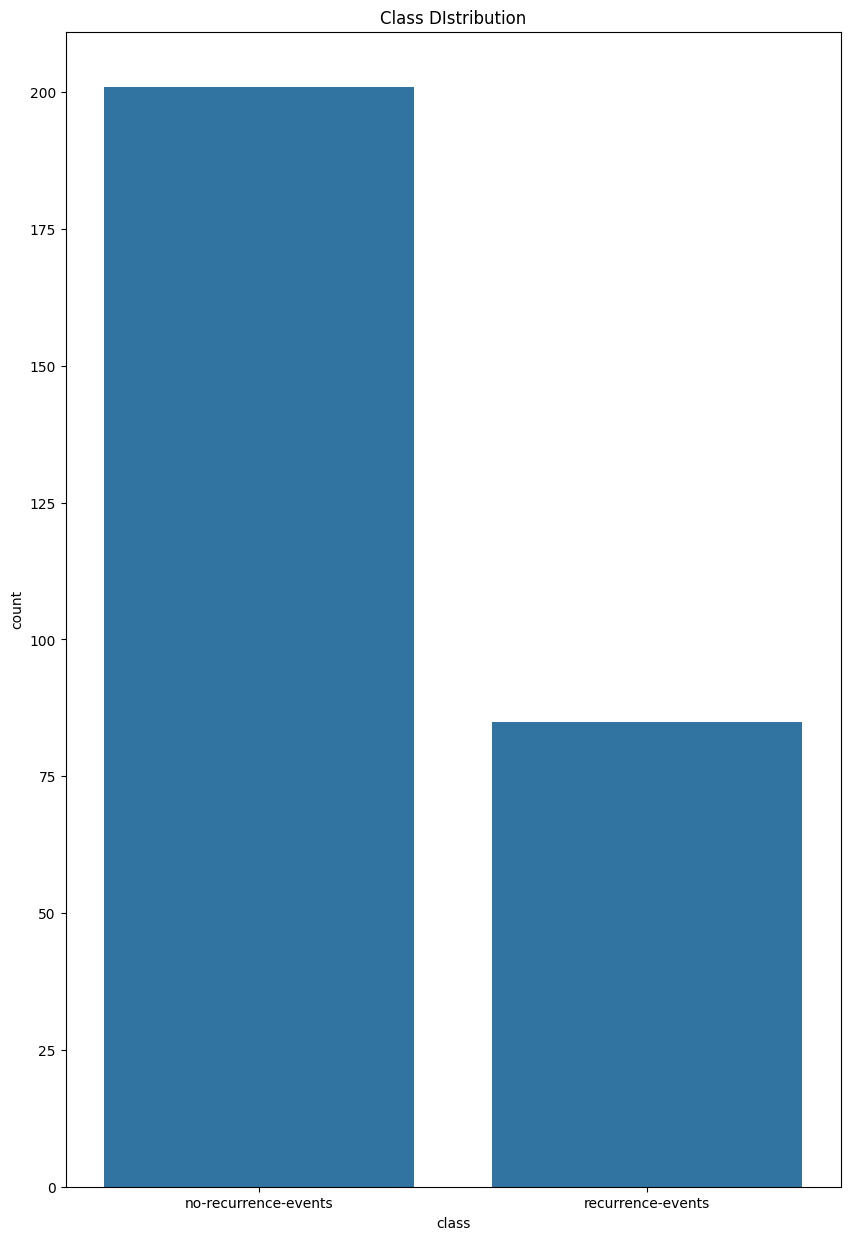

In [25]:
plt.figure(figsize=(10,15))
sns.countplot(x='class',data=df)
plt.title("Class DIstribution")
plt.show()

#### Cleaning Data

In [26]:
print((df == '?').sum())
df.isnull().sum()

class          0
age            0
menopause      0
tumor_size     0
inv_nodes      0
node_caps      8
deg_malig      0
breast         0
breast_quad    1
irradiat       0
dtype: int64


,0
class,0
age,0
menopause,0
tumor_size,0
inv_nodes,0
node_caps,0
deg_malig,0
breast,0
breast_quad,0
irradiat,0


In [27]:
df.replace('?', np.nan, inplace=True)
df['node_caps'] = df['node_caps'].fillna(df['node_caps'].mode()[0])
df['breast_quad'] = df['breast_quad'].fillna(df['breast_quad'].mode()[0])

print("Jumlah NaN setelah diisi:")
print(df.isnull().sum())

Jumlah NaN setelah diisi:
class          0
age            0
menopause      0
tumor_size     0
inv_nodes      0
node_caps      0
deg_malig      0
breast         0
breast_quad    0
irradiat       0
dtype: int64


### Label & Feature Encoding

In [28]:
X = df.drop("class", axis=1)
y = df["class"]

In [29]:
categorical_cols = X.columns

ct = ColumnTransformer(
    transformers=[
        ("encoder", OneHotEncoder(), categorical_cols)
    ],
    remainder="passthrough"
)

X = ct.fit_transform(X)

In [30]:
df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.columns:
    df_encoded[col] = df_encoded[col].astype(str)
    df_encoded[col] = le.fit_transform(df_encoded[col])



### Feature Correlation Check

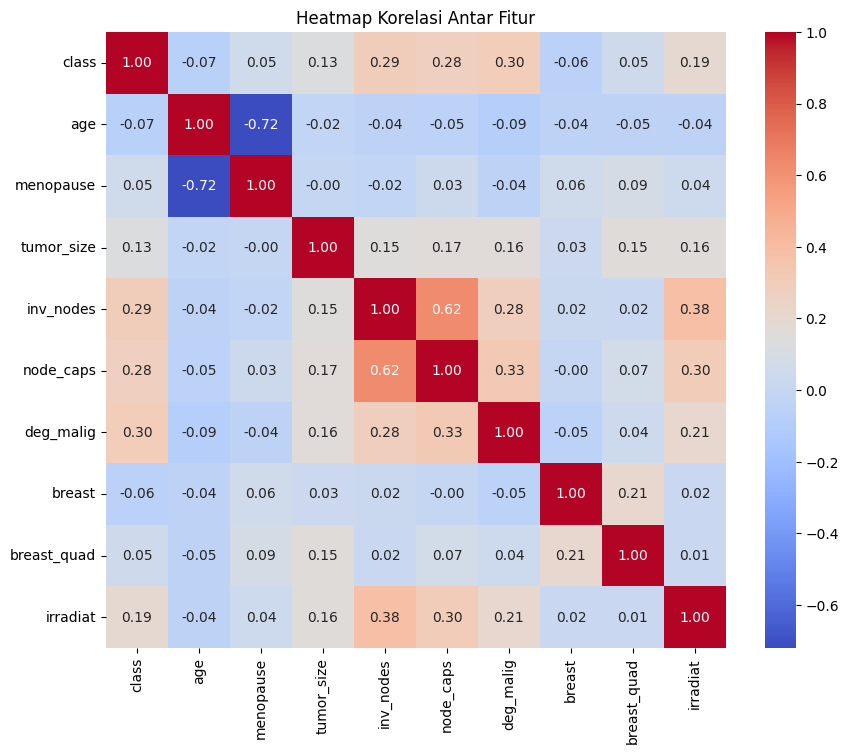

In [31]:
plt.figure(figsize=(10,8))
corr_matrix = df_encoded.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

In [32]:
df.head()

,class,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


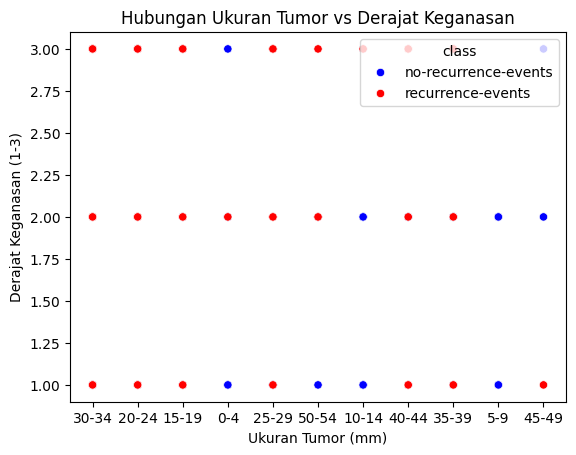

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x='tumor_size',
    y='deg_malig',
    hue='class',
    palette={'recurrence-events':'red', 'no-recurrence-events':'blue'}
)

plt.title("Hubungan Ukuran Tumor vs Derajat Keganasan")
plt.xlabel("Ukuran Tumor (mm)")
plt.ylabel("Derajat Keganasan (1-3)")
plt.show()

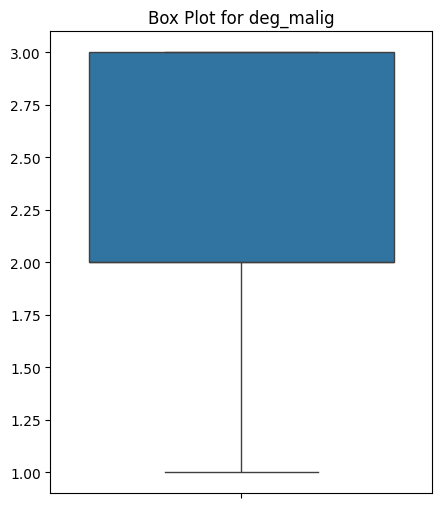

In [34]:
import math

numeric_column = df.select_dtypes(include=['int64','float64']).columns

ncols = 4
nrows = math.ceil(len(numeric_column) / ncols)

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 5*nrows))

axs = axs.flatten()

for i, column in enumerate(numeric_column):
    sns.boxplot(y=df[column], ax=axs[i], whis=1.5)
    axs[i].set_title(f'Box Plot for {column}')
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')

for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=0.5)
plt.show()

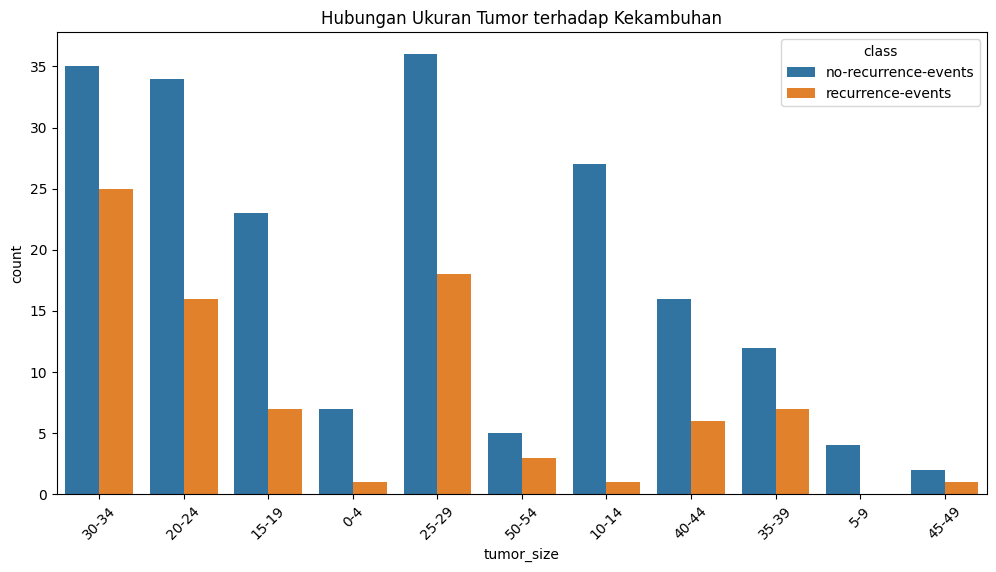

In [35]:
plt.figure(figsize=(12,6))
sns.countplot(x='tumor_size', hue='class', data=df)
plt.title('Hubungan Ukuran Tumor terhadap Kekambuhan')
plt.xticks(rotation=45)
plt.show()



### Data Preparation

#### Check Outliers

        Column  Outliers  Loss %
8     irradiat        68   23.78
3    inv_nodes        64   22.38
4    node_caps        56   19.58
7  breast_quad        33   11.54
2   tumor_size        12    4.20
0          age         7    2.45
1    menopause         0    0.00
6       breast         0    0.00
5    deg_malig         0    0.00


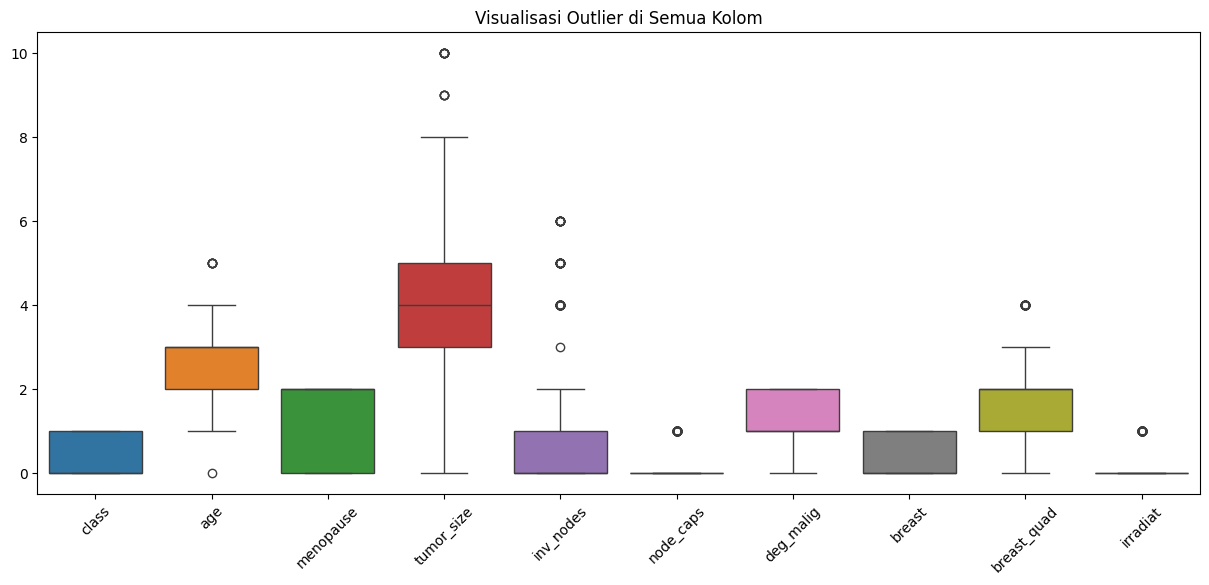

In [36]:

outlier_data = []

for column in df_encoded.columns:
    if column == 'class':
        continue

    Q1 = df_encoded[column].quantile(0.25)
    Q3 = df_encoded[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df_encoded[column] < lower_bound) | (df_encoded[column] > upper_bound)).sum()
    total_count = len(df_encoded)
    loss_percentage = (outlier_count / total_count) * 100

    outlier_data.append({
        'Column': column,
        'Outliers': outlier_count,
        'Loss %': round(loss_percentage, 2)
    })

df_outliers = pd.DataFrame(outlier_data)
print(df_outliers.sort_values(by='Outliers', ascending=False))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
sns.boxplot(data=df_encoded)
plt.xticks(rotation=45)
plt.title('Visualisasi Outlier di Semua Kolom')
plt.show()

### Scaling

irradiat
-0.558504    218
 1.790498     68
Name: count, dtype: int64


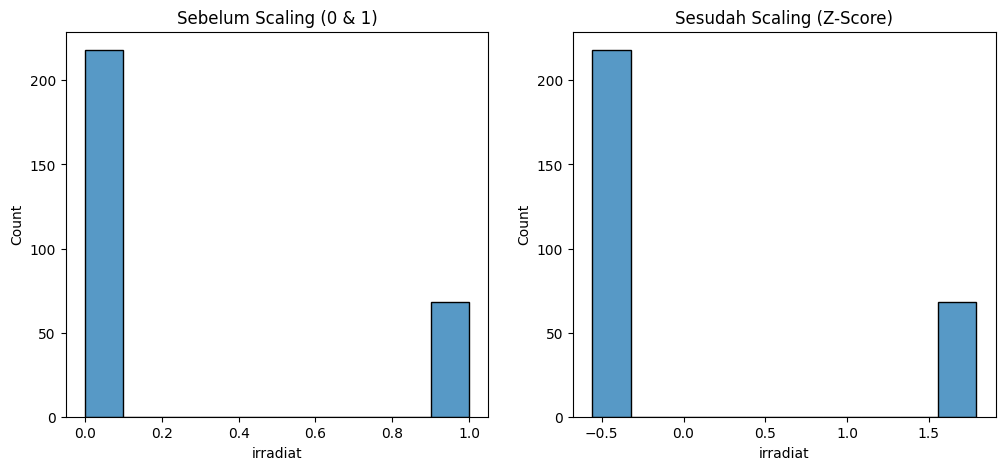

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
fitur = df_encoded.drop('class', axis=1)
nama_kolom = fitur.columns

fitur_scaled_array = scaler.fit_transform(fitur)

df_scaled = pd.DataFrame(fitur_scaled_array, columns=nama_kolom)
df_scaled['class'] = df_encoded['class'].values

print(df_scaled['irradiat'].value_counts())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_encoded['irradiat'], kde=False)
plt.title('Sebelum Scaling (0 & 1)')

plt.subplot(1, 2, 2)
sns.histplot(df_scaled['irradiat'], kde=False)
plt.title('Sesudah Scaling (Z-Score)')

plt.show()

### Feature Selection

In [76]:
df.head()

,class,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


In [79]:
selected_features = ['deg_malig', 'inv_nodes', 'node_caps', 'irradiat', 'tumor_size', 'age', 'menopause', 'breast_quad']

X = df_scaled[selected_features]
y = df_scaled['class']

print("Variabel X (Fitur) siap dengan kolom:", selected_features)
print("Variabel Y (Target) siap.")

Variabel X (Fitur) siap dengan kolom: ['deg_malig', 'inv_nodes', 'node_caps', 'irradiat', 'tumor_size', 'age', 'menopause', 'breast_quad']
Variabel Y (Target) siap.


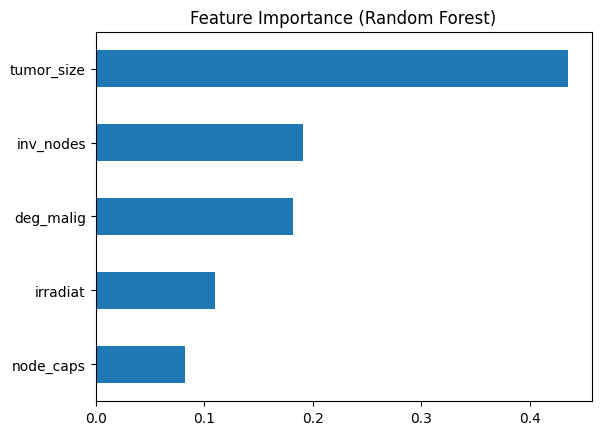

In [87]:
rf_model = models["Random Forest"]

importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=selected_features)

feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.show()

### Train Test Split

In [70]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)


In [88]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Random Forest
              precision    recall  f1-score   support

           0       0.76      0.80      0.78        40
           1       0.47      0.41      0.44        17

    accuracy                           0.68        57
   macro avg       0.61      0.61      0.61        57
weighted avg       0.67      0.68      0.68        57



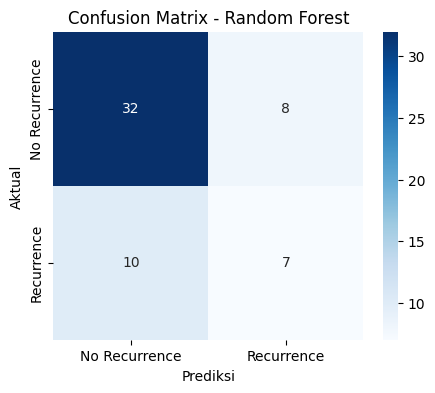


Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.62      0.70        40
           1       0.42      0.65      0.51        17

    accuracy                           0.63        57
   macro avg       0.61      0.64      0.61        57
weighted avg       0.69      0.63      0.65        57



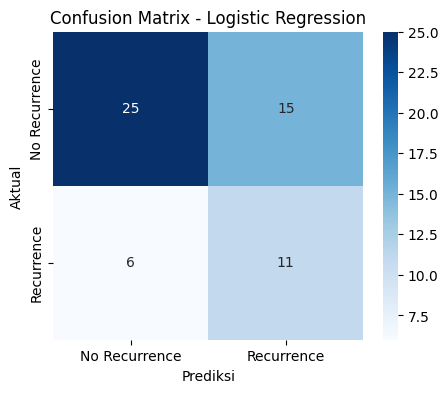


SVM
              precision    recall  f1-score   support

           0       0.79      0.65      0.71        40
           1       0.42      0.59      0.49        17

    accuracy                           0.63        57
   macro avg       0.60      0.62      0.60        57
weighted avg       0.68      0.63      0.65        57



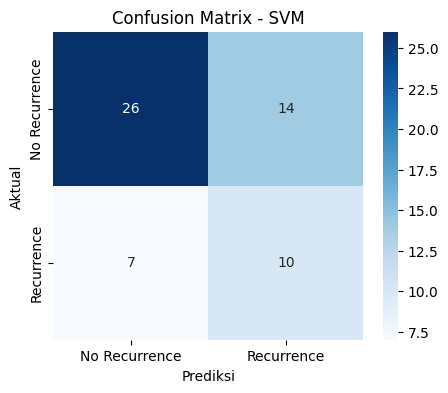

In [82]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight='balanced'),
    "Logistic Regression": LogisticRegression(class_weight='balanced'),
    "SVM": SVC(class_weight='balanced', probability=True)
}

for name, model in models.items():

    if name == "Random Forest":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)

    print(f"\n{name}")
    print(classification_report(y_val, y_pred))

    cm = confusion_matrix(y_val, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Recurrence', 'Recurrence'],
                yticklabels=['No Recurrence', 'Recurrence'])

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

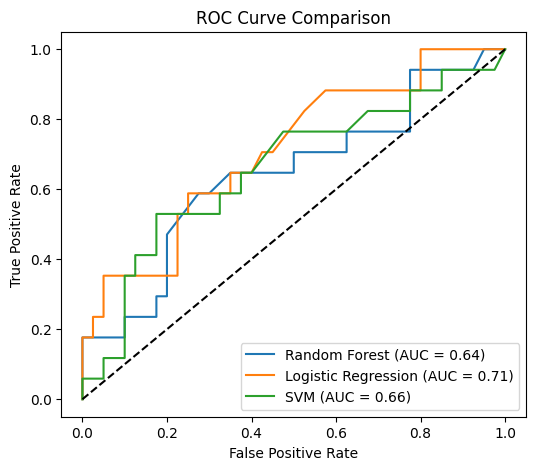

In [83]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(6,5))

for name, model in models.items():

    if name == "Random Forest":
        y_proba = model.predict_proba(X_val)[:, 1]
    else:
        y_proba = model.predict_proba(X_val_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [85]:
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

for t in [0.3, 0.4, 0.5]:
    y_pred = (y_proba > t).astype(int)

    from sklearn.metrics import recall_score, precision_score

    print(f"\nThreshold: {t}")
    print("Recall:", recall_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))


Threshold: 0.3
Recall: 0.8823529411764706
Precision: 0.3125

Threshold: 0.4
Recall: 0.6470588235294118
Precision: 0.4230769230769231

Threshold: 0.5
Recall: 0.6470588235294118
Precision: 0.4583333333333333
